In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
#importing the dataset
data = pd.read_csv('student_mental_health_burnout.csv')
data.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
data.shape

(150000, 20)

In [3]:
#Data Validation
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [12]:
#checking study, sleep, screen and physical activity are under 24 hrs combined
count=((data['daily_study_hours'] + data['daily_sleep_hours'] + data['screen_time_hours'] + data['physical_activity_hours'])>24).sum()
print(count)

24522


In [21]:
data.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='object')

In [20]:
data['daily_sleep_hours'].unique()

array([6.8, 4.7, 4.8, 6.7, 8. , 6.3, 5.4, 7. , 6. , 7.2, 5. , 7.9, 8.4,
       5.3, 5.1, 6.9, 8.6, 4. , 6.4, 8.2, 8.9, 8.7, 4.5, 7.5, 4.3, 6.6,
       8.3, 7.4, 4.9, 4.1, 4.4, 6.5, 5.9, 7.8, 5.6, 8.5, 6.1, 7.6, 5.8,
       5.5, 6.2, 7.7, 8.8, 5.7, 4.2, 7.3, 5.2, 4.6, 8.1, 7.1, 9. ])

In [29]:
data['academic_pressure_score'].unique()

array([ 4,  8,  6,  9,  3,  7,  1, 10,  5,  2])

In [31]:
#checking for duplicates 
data.duplicated().sum()

np.int64(0)

In [33]:
data['burnout_level'].value_counts()

burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64

In [35]:
#separating numerical and categorical columns for EDA
num_cols = [col for col in data if data[col].dtype != 'O']
print(num_cols)

['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours', 'attendance_percentage', 'cgpa']


In [36]:
cat_cols = [col for col in data if data[col].dtype == 'O']
print(cat_cols)

['gender', 'course', 'year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']


In [39]:
#checking unique values in categorical columns to identify any typos or inconsistent labels 
for col in cat_cols:
    print(f'{col} unique values are: {data[col].unique()}\n')

gender unique values are: ['Male' 'Female' 'Other']

course unique values are: ['BTech' 'BCA' 'BSc' 'MBA' 'MCA' 'BBA']

year unique values are: ['1st' '3rd' '4th' '2nd']

stress_level unique values are: ['High' 'Low' 'Medium']

sleep_quality unique values are: ['Average' 'Poor' 'Good']

internet_quality unique values are: ['Good' 'Poor' 'Average']

burnout_level unique values are: ['High' 'Low' 'Medium']



<Axes: xlabel='burnout_level', ylabel='count'>

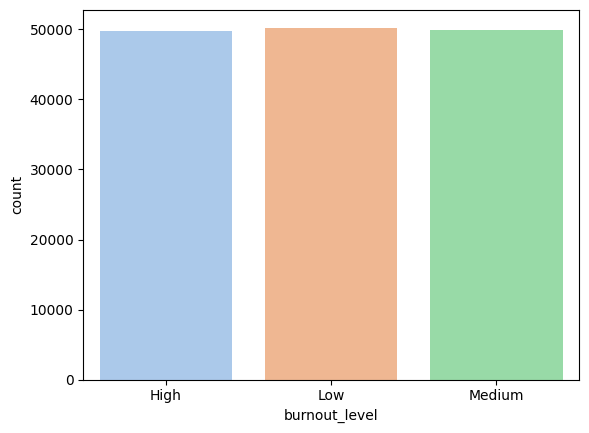

In [40]:
#univariate Analysis
sns.countplot(x='burnout_level',data = data, palette = 'pastel')

<Axes: xlabel='daily_study_hours', ylabel='Count'>

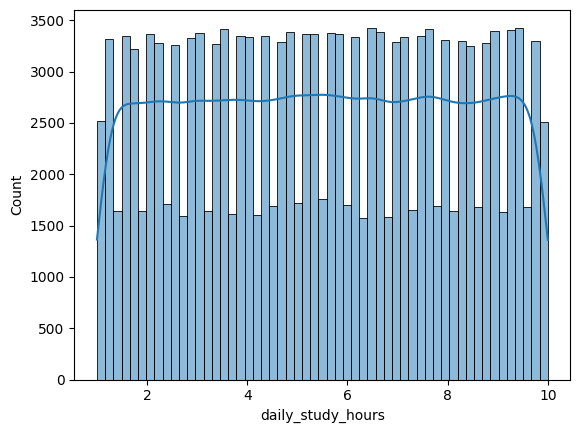

In [44]:
sns.histplot(data['daily_study_hours'],kde=True)

<Axes: xlabel='daily_sleep_hours'>

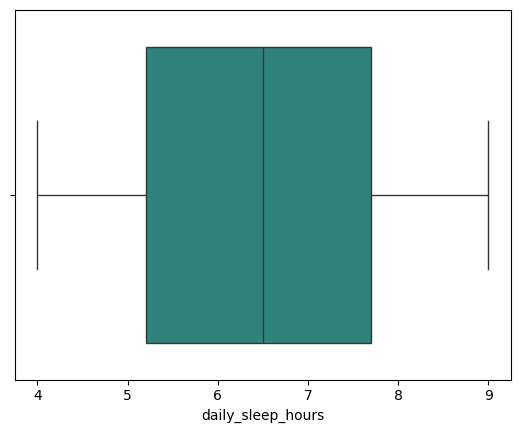

In [48]:
sns.boxplot(x ='daily_sleep_hours',data = data,palette ='viridis')

Text(0.5, 1.0, 'stress level distribution')

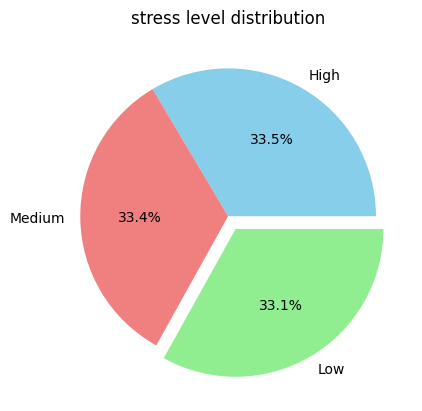

In [62]:
#univariate analysis for categorical columns
#piechart
data['stress_level'].value_counts().plot.pie(autopct = '%1.1f%%',colors=['skyblue','lightcoral','lightgreen'],explode = (0,0,0.1))
plt.ylabel('')
plt.title('stress level distribution')

Text(0.5, 1.0, 'Distribution of Internet Quality')

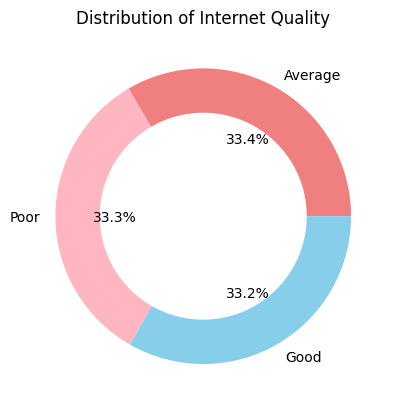

In [64]:
#donut plot
data['internet_quality'].value_counts().plot.pie(autopct ='%1.1f%%',colors = ['lightcoral','lightpink','skyblue'],wedgeprops = dict(width=0.3))
plt.ylabel('')
plt.title('Distribution of Internet Quality')

<Axes: xlabel='anxiety_score', ylabel='daily_study_hours'>

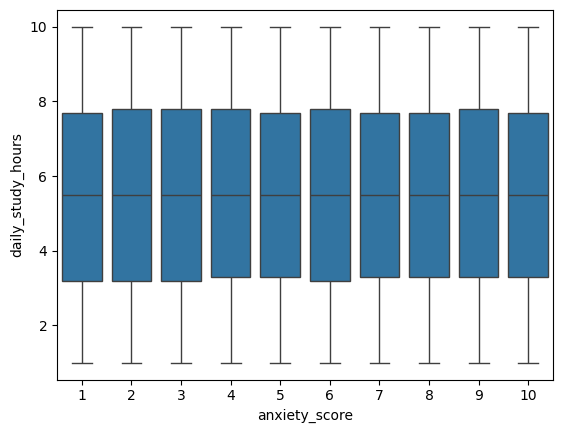

In [69]:
#bivariate analysis
sns.boxplot(x='anxiety_score', y='daily_study_hours', data=data)

<Axes: xlabel='burnout_level', ylabel='stress_level'>

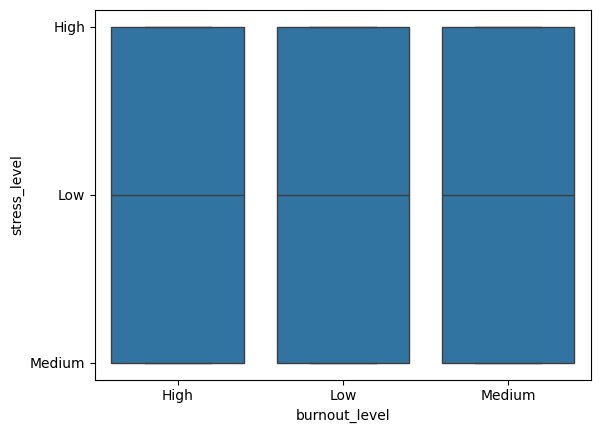

In [70]:
sns.boxplot(x='burnout_level', y='stress_level', data=data)

<Axes: >

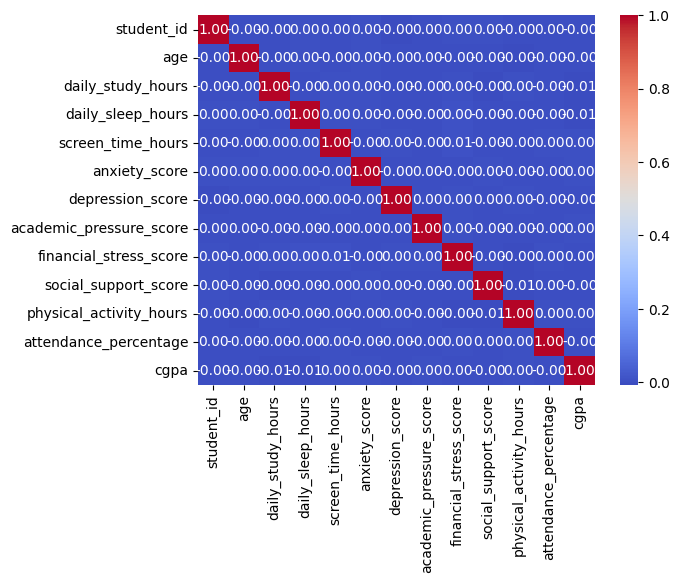

In [71]:
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)